# Install dependencies & Imports

In [ ]:

!pip -q install tensorflow seaborn scikit-learn pandas matplotlib

import os, shutil, zipfile, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#Dataset Upload and Preprocessing Setup

In [ ]:
from google.colab import files

print("Upload your archive.zip file:")
uploaded = files.upload()

zip_path = list(uploaded.keys())[0]
extract_dir = "/content/rice_dataset"

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

def find_data_root(base):
    for root, dirs, files_ in os.walk(base):
        if len(dirs) >= 2 and not any(f.endswith(".py") for f in files_):
            sample_subdir = os.path.join(root, dirs[0])
            imgs = [f for f in os.listdir(sample_subdir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))]
            if imgs:
                return root
    return base

DATA_DIR = find_data_root(extract_dir)
CLASS_NAMES = sorted(os.listdir(DATA_DIR))
print("\nData directory:", DATA_DIR)
print("Classes found:", CLASS_NAMES)

for c in CLASS_NAMES:
    n = len(os.listdir(os.path.join(DATA_DIR, c)))
    print(f"  {c}: {n} images")


Upload your archive.zip file:


Saving archive.zip to archive.zip

Data directory: /content/rice_dataset/rice_leaf_diseases
Classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
  Bacterial leaf blight: 40 images
  Brown spot: 40 images
  Leaf smut: 40 images


#Model Configuration

In [ ]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 8
SEED        = 42
EPOCHS      = 50
NUM_CLASSES = len(CLASS_NAMES)
AUTOTUNE    = tf.data.AUTOTUNE

print(f"Classes: {NUM_CLASSES} | Image size: {IMG_SIZE} | Batch: {BATCH_SIZE}")

Classes: 3 | Image size: (224, 224) | Batch: 8


#Training and Validation Dataset Preparation (80/20 Split)

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
print("Class order:", class_names)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 120 files belonging to 3 classes.
Using 96 files for training.
Found 120 files belonging to 3 classes.
Using 24 files for validation.
Class order: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


#Sample Image Visualization

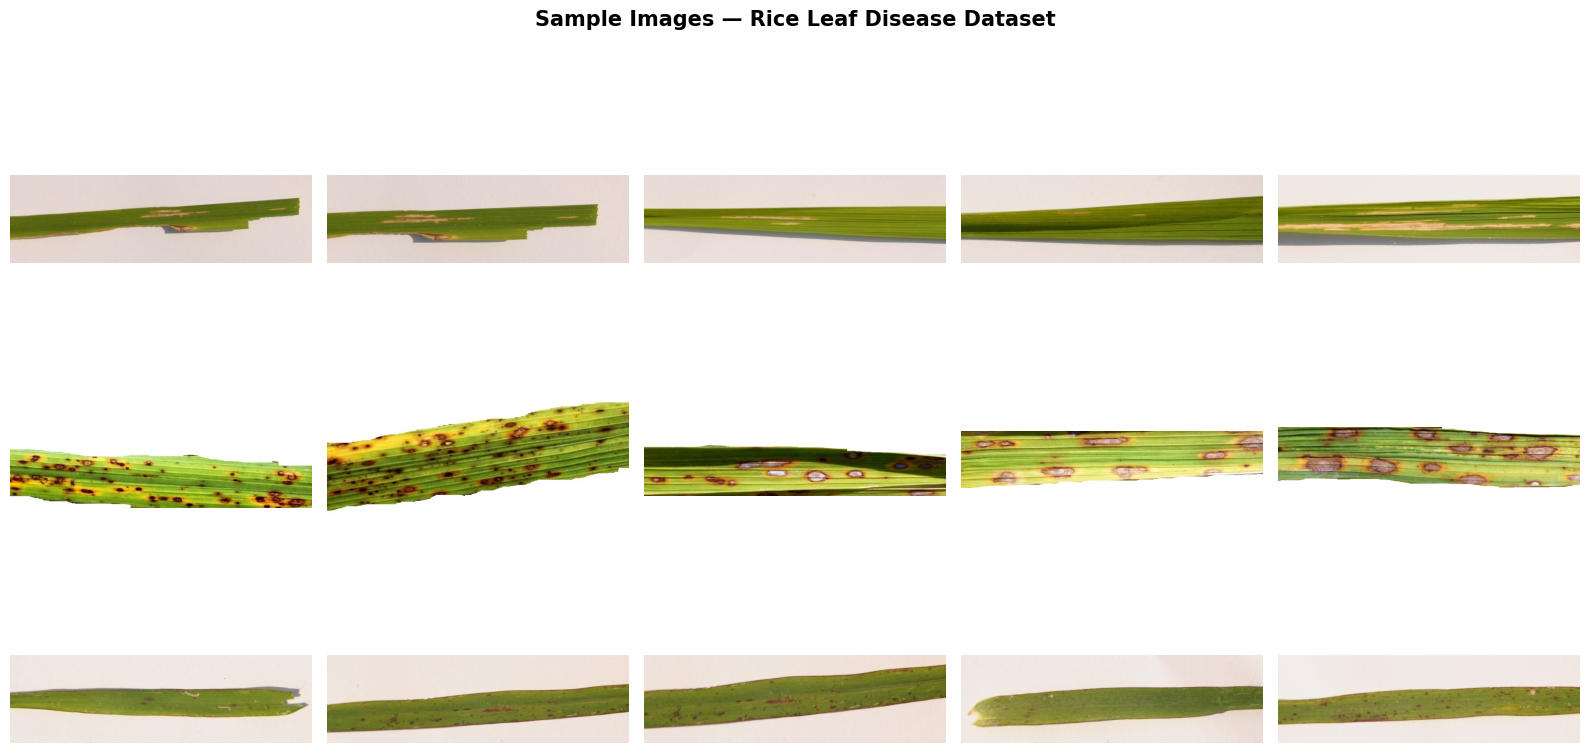

In [ ]:
counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in class_names}

fig, axes = plt.subplots(3, 5, figsize=(16, 9))
fig.suptitle("Sample Images — Rice Leaf Disease Dataset", fontsize=15, fontweight="bold")

for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    imgs = sorted([f for f in os.listdir(class_dir)
                   if f.lower().endswith((".jpg", ".jpeg", ".png"))])[:5]
    for col, img_name in enumerate(imgs):
        img = plt.imread(os.path.join(class_dir, img_name))
        axes[class_idx, col].imshow(img)
        axes[class_idx, col].axis("off")
        if col == 0:
            axes[class_idx, col].set_ylabel(class_name, fontsize=10,
                                             fontweight="bold", rotation=0,
                                             labelpad=120, va="center")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

# Class Distribution Analysis

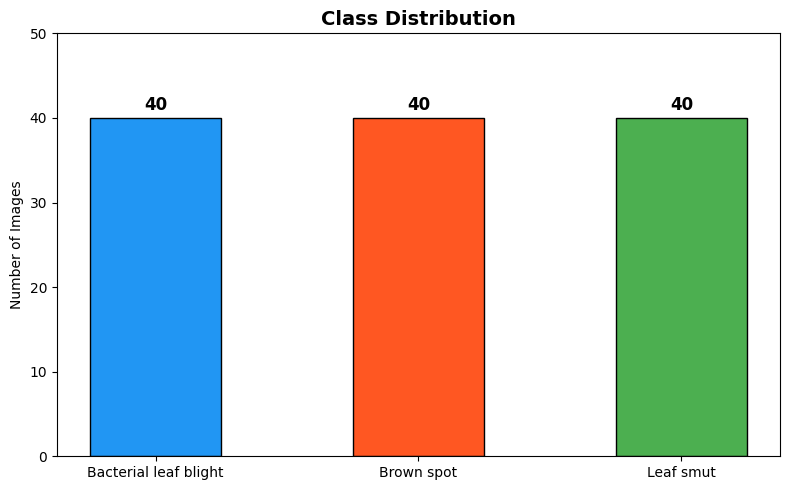

Dataset is perfectly balanced: {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.keys(), counts.values(),
              color=["#2196F3", "#FF5722", "#4CAF50"], edgecolor="black", width=0.5)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(counts.values()) + 10)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dataset is perfectly balanced:", counts)

# Data Augmentation Pipeline

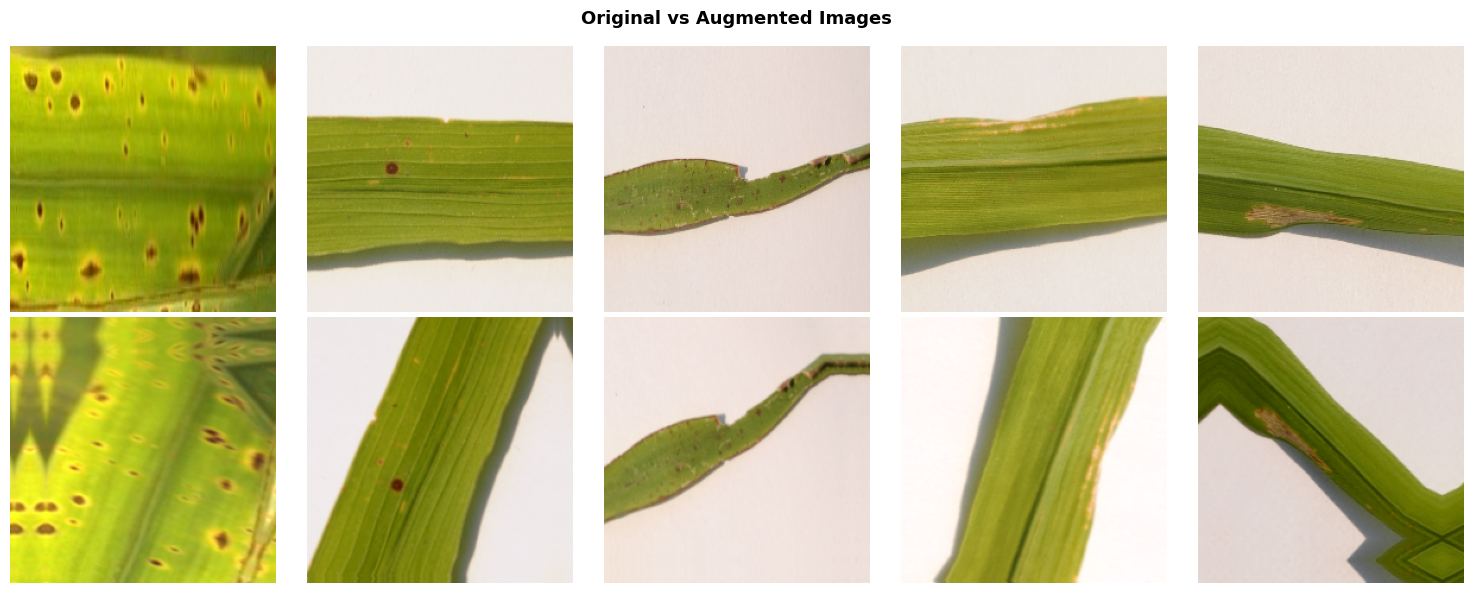

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.10),
    layers.RandomTranslation(0.10, 0.10),
], name="augmentation")
train_ds_aug = (
    train_ds
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .shuffle(500, seed=SEED)
    .prefetch(AUTOTUNE)
)
sample_images, _ = next(iter(train_ds.take(1)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Original vs Augmented Images", fontsize=13, fontweight="bold")
for i in range(min(5, len(sample_images))):
    img = sample_images[i].numpy().astype("uint8")
    aug_img = data_augmentation(tf.expand_dims(sample_images[i], 0),
                                 training=True)[0].numpy().clip(0, 255).astype("uint8")
    axes[0, i].imshow(img);  axes[0, i].axis("off")
    axes[1, i].imshow(aug_img); axes[1, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=10, fontweight="bold")
        axes[1, i].set_ylabel("Augmented", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()


# Custom CNN Architecture

In [ ]:
def build_custom_cnn(num_classes, input_shape=(224, 224, 3)):

    inputs = keras.Input(shape=input_shape, name="input")

    x = layers.Rescaling(1.0 / 255)(inputs)

    x = layers.Conv2D(32, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(256, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Conv2D(512, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs, outputs, name="Custom_CNN")
    return model

cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.summary()
print(f"\nTotal parameters: {cnn_model.count_params():,}")


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,02

 Total params: 2,523,939 (9.63 MB)

 Trainable params: 2,520,483 (9.61 MB)

 Non-trainable params: 3,456 (13.50 KB)


Total parameters: 2,523,939


# Transfer Learning Models

In [ ]:
def build_transfer_model(model_name, num_classes, input_shape=(224, 224, 3)):
    backbone_map = {
        "EfficientNetV2B0": (
            tf.keras.applications.EfficientNetV2B0,
            tf.keras.applications.efficientnet_v2.preprocess_input
        ),
        "MobileNetV3Large": (
            tf.keras.applications.MobileNetV3Large,
            tf.keras.applications.mobilenet_v3.preprocess_input
        ),
        "ResNet50V2": (
            tf.keras.applications.ResNet50V2,
            tf.keras.applications.resnet_v2.preprocess_input
        ),
        "DenseNet121": (
            tf.keras.applications.DenseNet121,
            tf.keras.applications.densenet.preprocess_input
        ),
    }

    if model_name not in backbone_map:
        raise ValueError(f"Unknown model: {model_name}")

    BackboneCls, preprocess_fn = backbone_map[model_name]
    base = BackboneCls(include_top=False, weights="imagenet",
                       input_shape=input_shape)
    base.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = layers.Lambda(preprocess_fn)(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model


# Training Utility  (Warm-up + Fine-tune)

In [ ]:
def compile_and_train(model, train_data, val_data, epochs=EPOCHS,
                      model_name="model", is_transfer=False):

    warmup_lr   = 1e-3 if not is_transfer else 1e-3
    finetune_lr = 1e-5

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=warmup_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks_warmup = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=7,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy", factor=0.5,
            patience=4, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            f"{model_name}_warmup.keras",
            monitor="val_accuracy", save_best_only=True, verbose=0
        )
    ]

    print(f"\n{'='*55}")
    print(f"  [{model_name}]  Phase 1 — Warm-up (frozen backbone)")
    print(f"{'='*55}")

    warmup_epochs = min(30, epochs)
    history_warmup = model.fit(
        train_data, validation_data=val_data,
        epochs=warmup_epochs, callbacks=callbacks_warmup, verbose=1
    )

    history_finetune = None
    if is_transfer:
        base_model = next(l for l in model.layers
                          if isinstance(l, tf.keras.Model))
        base_model.trainable = True
        for layer in base_model.layers[:-30]:
            layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=finetune_lr),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        callbacks_ft = [
            keras.callbacks.EarlyStopping(
                monitor="val_accuracy", patience=7,
                restore_best_weights=True, verbose=1
            ),
            keras.callbacks.ModelCheckpoint(
                f"{model_name}_best.keras",
                monitor="val_accuracy", save_best_only=True, verbose=0
            )
        ]

        print(f"\n  [{model_name}]  Phase 2 — Fine-tuning (top 30 layers, lr=1e-5)")
        finetune_epochs = min(20, epochs)
        history_finetune = model.fit(
            train_data, validation_data=val_data,
            epochs=finetune_epochs, callbacks=callbacks_ft, verbose=1
        )
    y_true, y_pred = [], []
    for images, labels in val_data:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())


    combined_history = {}
    for key in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        warmup_vals   = history_warmup.history.get(key, [])
        finetune_vals = history_finetune.history.get(key, []) if history_finetune else []
        combined_history[key] = warmup_vals + finetune_vals

    return model, combined_history, y_true, y_pred



# Model Training and Evaluation Pipeline

In [ ]:
MODELS_TO_RUN = {
    "Custom_CNN":       (cnn_model, False),
    "EfficientNetV2B0": (build_transfer_model("EfficientNetV2B0", NUM_CLASSES), True),
    "MobileNetV3Large": (build_transfer_model("MobileNetV3Large", NUM_CLASSES), True),
    "ResNet50V2":       (build_transfer_model("ResNet50V2",       NUM_CLASSES), True),
    "DenseNet121":      (build_transfer_model("DenseNet121",      NUM_CLASSES), True),
}

all_results   = []
all_histories = {}
all_preds     = {}

for name, (model, is_transfer) in MODELS_TO_RUN.items():
    train_data = train_ds_aug

    trained_model, history, y_true, y_pred = compile_and_train(
        model, train_data, val_ds,
        epochs=EPOCHS, model_name=name, is_transfer=is_transfer
    )

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred,    average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred,        average="weighted", zero_division=0)

    all_results.append({
        "Model": name, "Accuracy": round(acc, 4),
        "Precision": round(prec, 4), "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "Params (M)": round(model.count_params() / 1e6, 2)
    })
    all_histories[name] = history
    all_preds[name]     = (y_true, y_pred, trained_model)

    print(f"\n  {name} → Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}")


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  [Custom_CNN]  Phase 1 — Warm-up (frozen backbone)
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 360ms/step - accuracy: 0.4792 - loss: 1.5730 - val_accuracy: 0.3333 - val_loss: 1.2561 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5208 - loss: 1.5919 - val_accuracy: 0.2083 - val_loss: 1.4897 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4583 - loss: 1.6819 - val_accuracy: 0.2083 - val_loss: 3.1558 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.4583 - loss: 1.5621 - val_accuracy: 0.4583 - val_loss: 1.3797 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4688 - loss: 1.4725 - val_accuracy: 0.4583 - val_loss: 1.4334 - learning


  DenseNet121 → Acc=0.8750  P=0.8715  R=0.8750  F1=0.8708


# Results Table

In [ ]:
results_df = (pd.DataFrame(all_results)
              .sort_values("Accuracy", ascending=False)
              .reset_index(drop=True))

print("\n" + "="*75)
print("FINAL MODEL COMPARISON")
print("="*75)
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison_results.csv", index=False)
print("\nSaved → model_comparison_results.csv")



FINAL MODEL COMPARISON
           Model  Accuracy  Precision  Recall  F1 Score  Params (M)
MobileNetV3Large    0.9583     0.9630  0.9583    0.9586        3.12
      ResNet50V2    0.9167     0.9295  0.9167    0.9097       23.83
EfficientNetV2B0    0.9167     0.9295  0.9167    0.9164        6.08
     DenseNet121    0.8750     0.8715  0.8750    0.8708        7.17
      Custom_CNN    0.4583     0.2101  0.4583    0.2881        2.52

Saved → model_comparison_results.csv


# Learning Curves for All Models

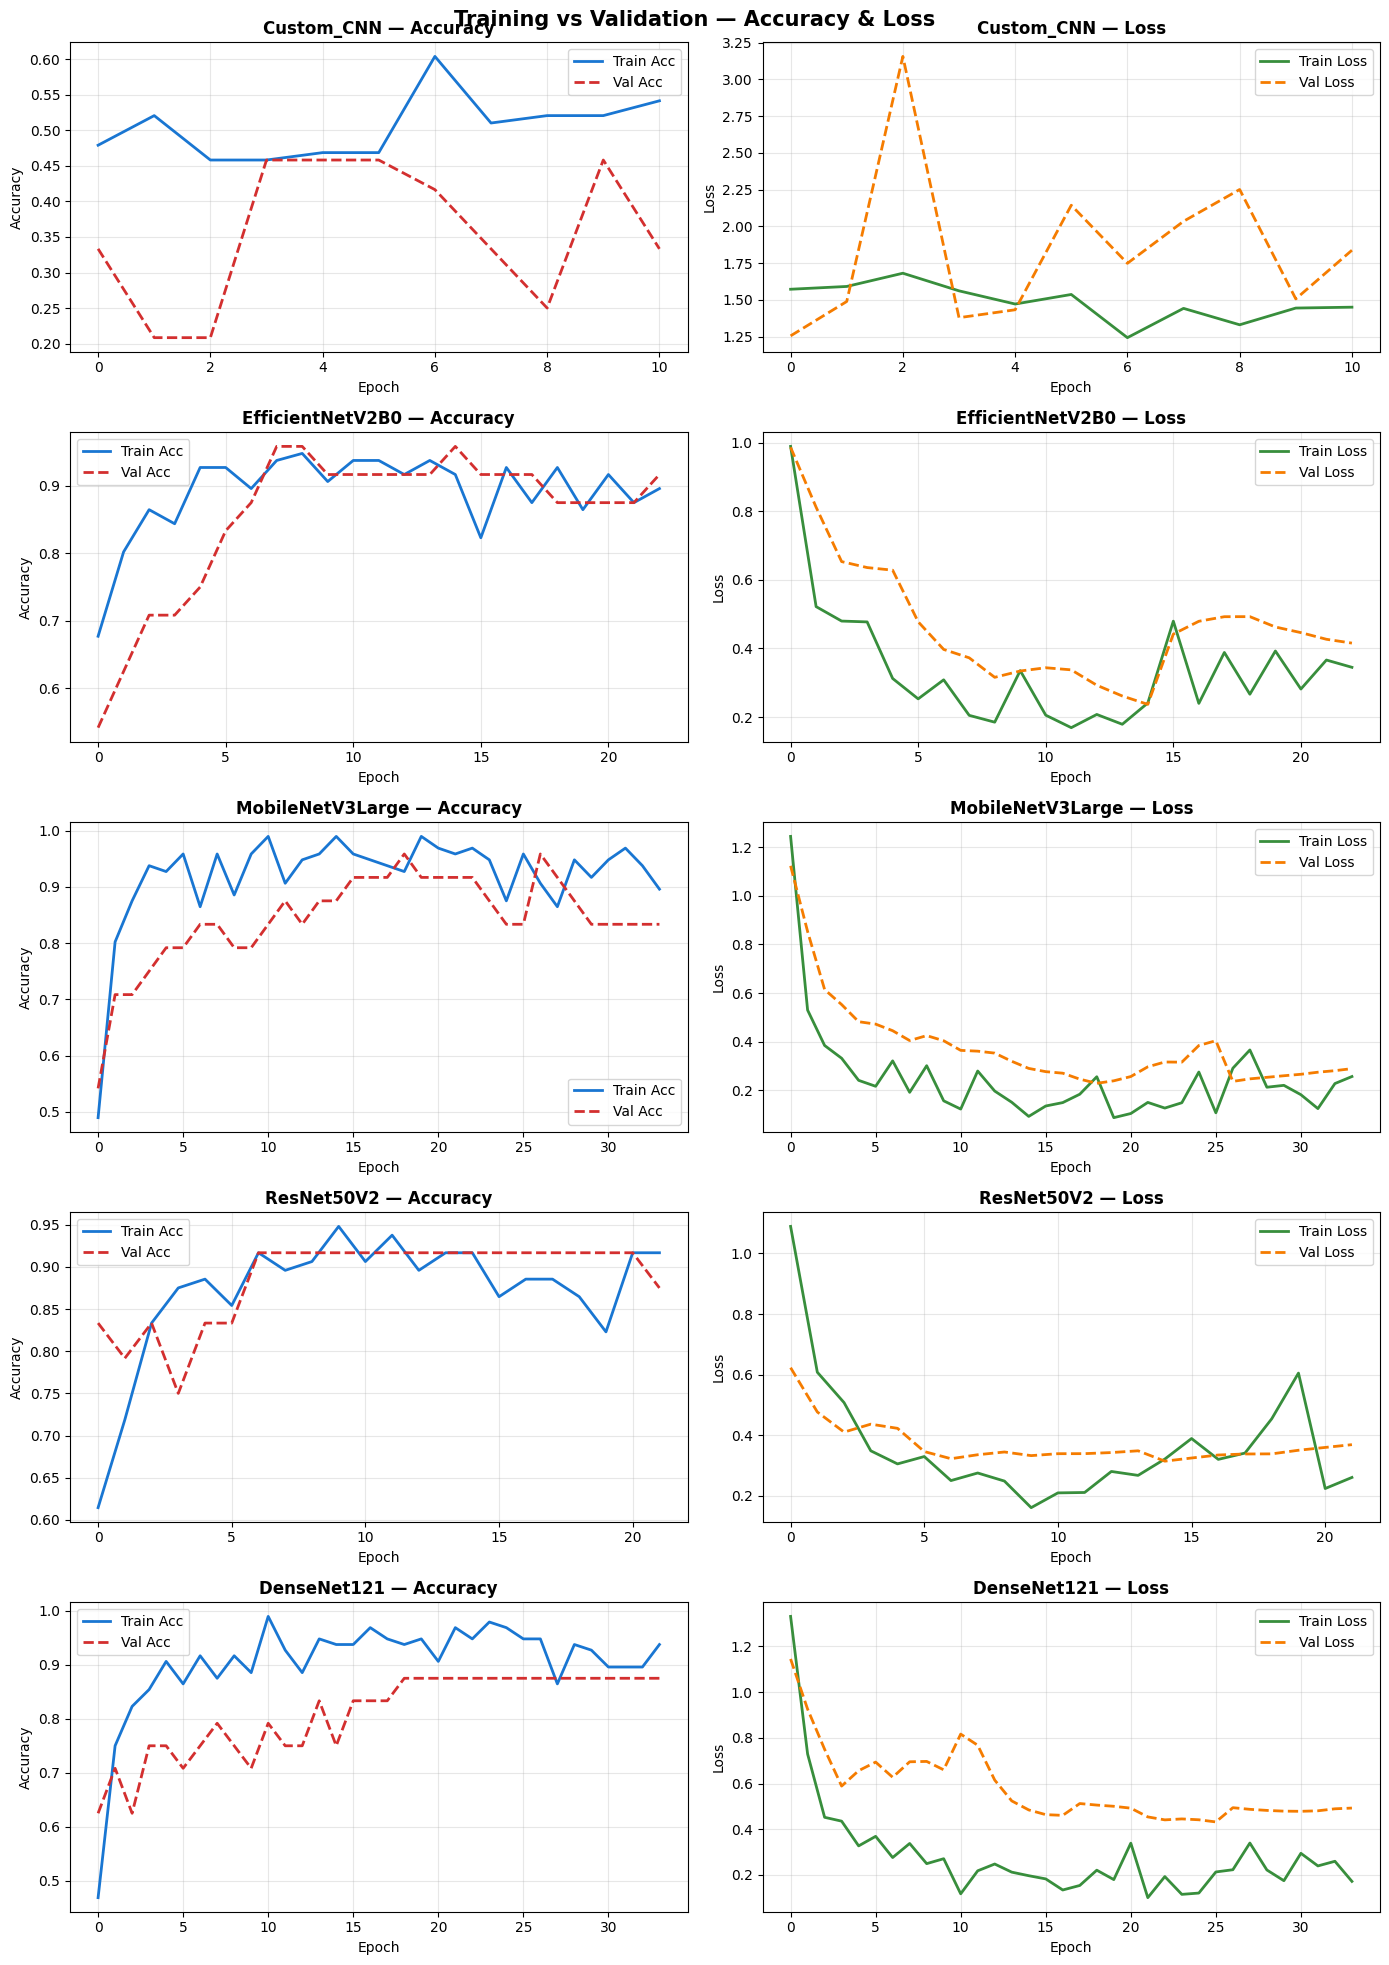

In [ ]:
n_models = len(all_histories)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models))
fig.suptitle("Training vs Validation — Accuracy & Loss", fontsize=15, fontweight="bold")

for i, (name, hist) in enumerate(all_histories.items()):
    ax_acc, ax_loss = axes[i, 0], axes[i, 1]
    ax_acc.plot(hist["accuracy"],     label="Train Acc",  color="#1976D2", lw=2)
    ax_acc.plot(hist["val_accuracy"], label="Val Acc",   color="#D32F2F", lw=2, ls="--")
    ax_acc.set_title(f"{name} — Accuracy", fontweight="bold")
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(); ax_acc.grid(alpha=0.3)

    ax_loss.plot(hist["loss"],     label="Train Loss", color="#388E3C", lw=2)
    ax_loss.plot(hist["val_loss"], label="Val Loss",  color="#F57C00", lw=2, ls="--")
    ax_loss.set_title(f"{name} — Loss", fontweight="bold")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Accuracy Comparison Bar Chart

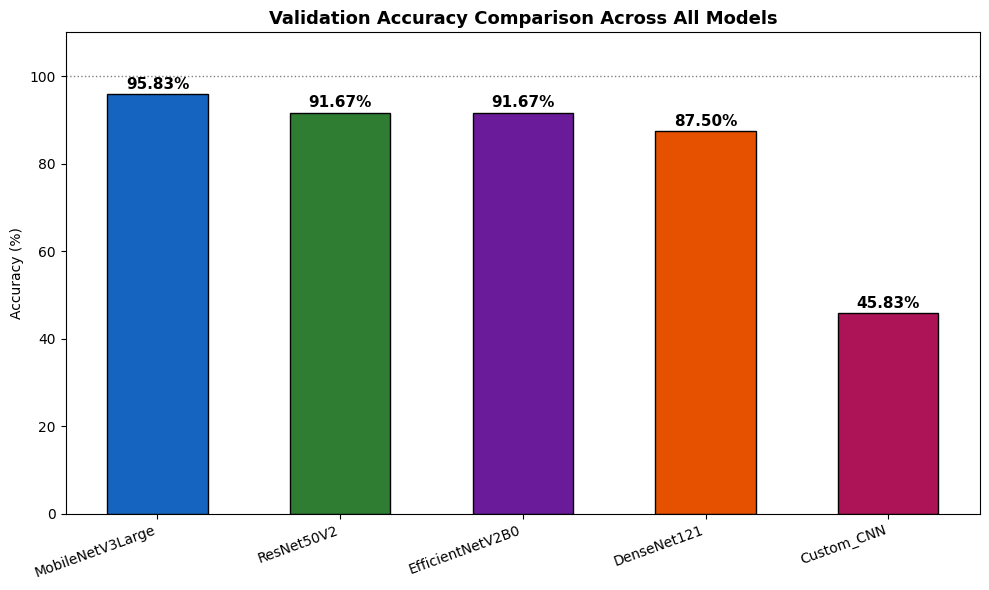

In [ ]:
palette = ["#1565C0", "#2E7D32", "#6A1B9A", "#E65100", "#AD1457"]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results_df["Model"], results_df["Accuracy"] * 100,
              color=palette[:len(results_df)], edgecolor="black", width=0.55)
for bar, val in zip(bars, results_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5, f"{val*100:.2f}%",
            ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Validation Accuracy Comparison Across All Models",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.axhline(y=100, color="gray", ls=":", lw=1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# Grouped Metrics Bar Chart

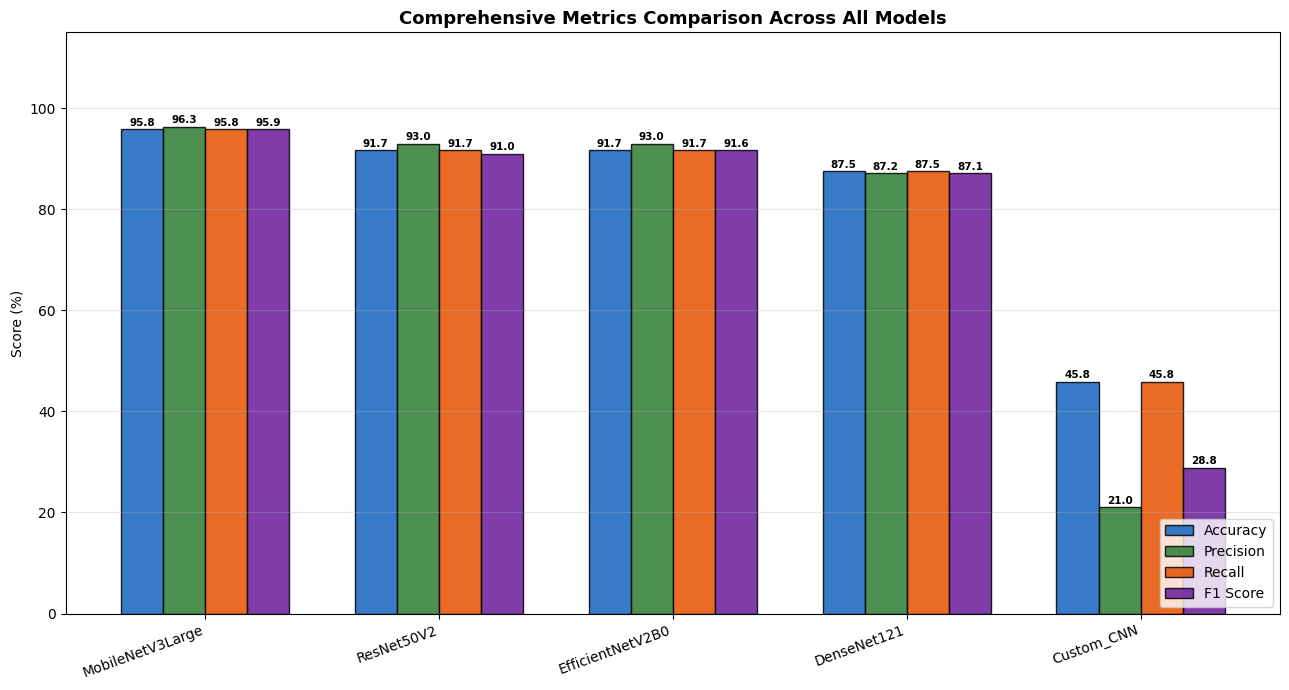

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(results_df))
width = 0.18
colors = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]

fig, ax = plt.subplots(figsize=(13, 7))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results_df[metric] * 100
    rects = ax.bar(x + i * width, vals, width, label=metric,
                   color=color, edgecolor="black", alpha=0.85)
    for rect, val in zip(rects, vals):
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + 0.3, f"{val:.1f}",
                ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=20, ha="right")
ax.set_ylabel("Score (%)")
ax.set_title("Comprehensive Metrics Comparison Across All Models",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 115)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# F1 Score Ranking

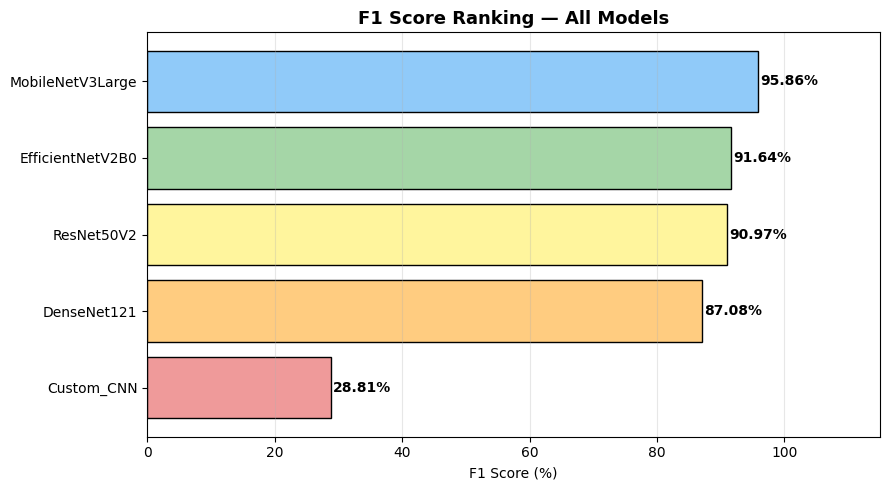

In [ ]:
f1_sorted = results_df.sort_values("F1 Score", ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(f1_sorted["Model"], f1_sorted["F1 Score"] * 100,
               color=["#EF9A9A", "#FFCC80", "#FFF59D", "#A5D6A7", "#90CAF9"][:len(f1_sorted)],
               edgecolor="black")
for bar, val in zip(bars, f1_sorted["F1 Score"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val*100:.2f}%", va="center", fontweight="bold")
ax.set_xlabel("F1 Score (%)")
ax.set_title("F1 Score Ranking — All Models", fontsize=13, fontweight="bold")
ax.set_xlim(0, 115)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("f1_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

# Model Complexity vs Accuracy Scatter

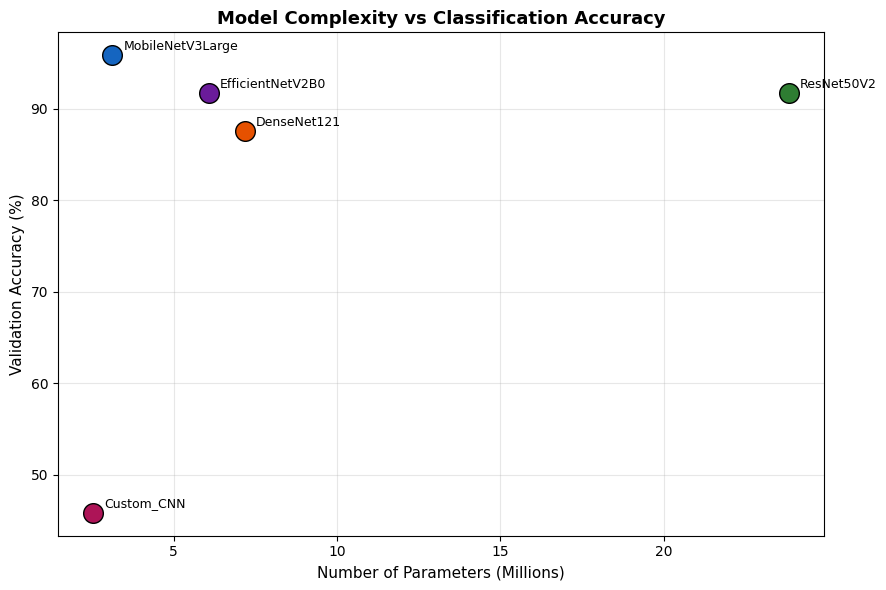

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
colors_scatter = ["#1565C0", "#2E7D32", "#6A1B9A", "#E65100", "#AD1457"]
for i, row in results_df.iterrows():
    ax.scatter(row["Params (M)"], row["Accuracy"] * 100,
               s=200, color=colors_scatter[i % len(colors_scatter)],
               zorder=5, edgecolors="black")
    ax.annotate(row["Model"], (row["Params (M)"], row["Accuracy"] * 100),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("Number of Parameters (Millions)", fontsize=11)
ax.set_ylabel("Validation Accuracy (%)", fontsize=11)
ax.set_title("Model Complexity vs Classification Accuracy",
             fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("complexity_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion Matrices for All Models

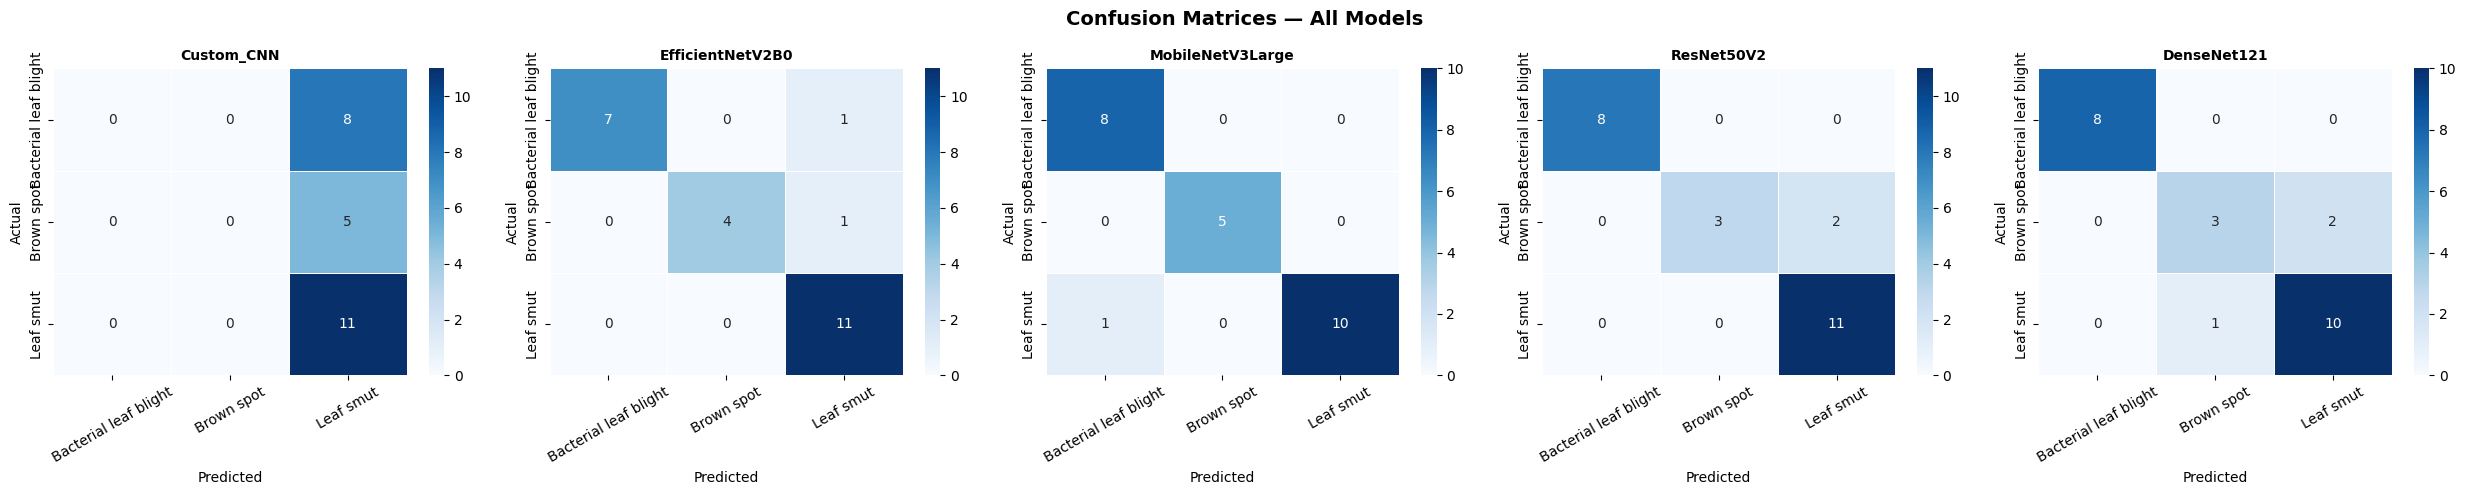

In [ ]:
n = len(all_preds)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")

for ax, (name, (y_true, y_pred, _)) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5)
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()

# Best Model Confusion Matrix

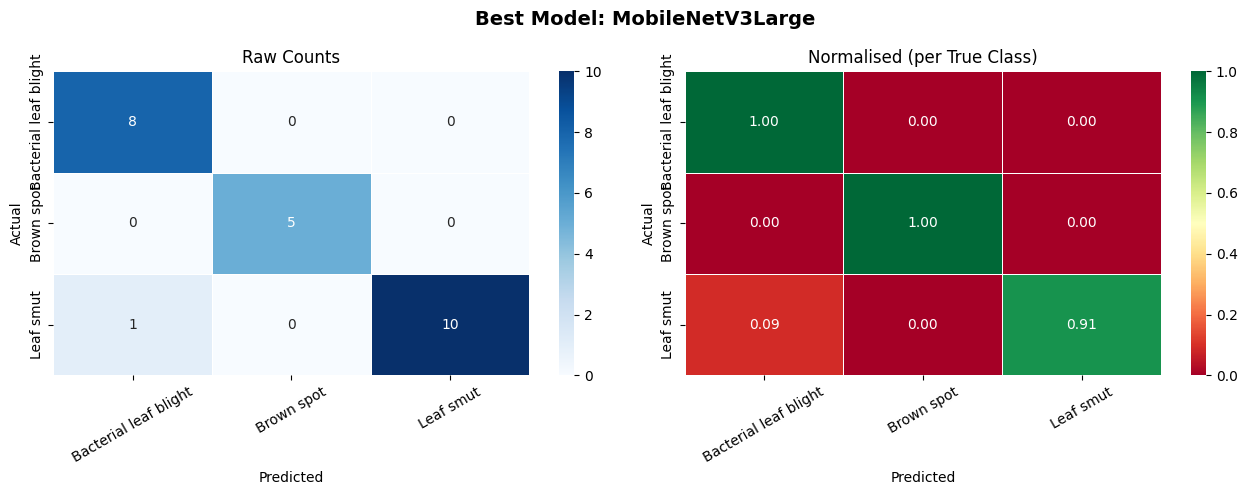

In [ ]:
best_name = results_df.iloc[0]["Model"]
y_true_b, y_pred_b, best_model = all_preds[best_name]

cm = confusion_matrix(y_true_b, y_pred_b)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Best Model: {best_name}", fontsize=14, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
ax1.set_title("Raw Counts"); ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")
ax1.tick_params(axis="x", rotation=30)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax2,
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1, linewidths=0.5)
ax2.set_title("Normalised (per True Class)")
ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"confusion_matrix_{best_name}.png", dpi=150, bbox_inches="tight")
plt.show()

# Radar Chart of top 2 Models

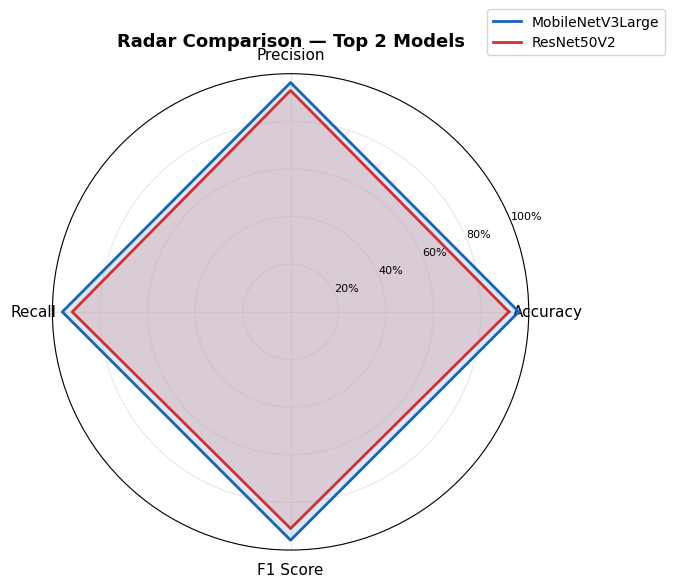

In [ ]:
top2 = results_df.head(2)
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
angles = np.linspace(0, 2 * np.pi, len(metric_labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_title("Radar Comparison — Top 2 Models", fontsize=13,
             fontweight="bold", pad=20)

radar_colors = ["#1565C0", "#D32F2F"]
for (_, row), color in zip(top2.iterrows(), radar_colors):
    vals = [row[m] for m in metric_labels] + [row[metric_labels[0]]]
    ax.plot(angles, vals, color=color, lw=2, label=row["Model"])
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=8)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("radar_top2.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-Class Precision, Recall and F1 Breakdown


  DETAILED CLASSIFICATION REPORT — MobileNetV3Large
                       precision    recall  f1-score   support

Bacterial leaf blight     0.8889    1.0000    0.9412         8
           Brown spot     1.0000    1.0000    1.0000         5
            Leaf smut     1.0000    0.9091    0.9524        11

             accuracy                         0.9583        24
            macro avg     0.9630    0.9697    0.9645        24
         weighted avg     0.9630    0.9583    0.9586        24



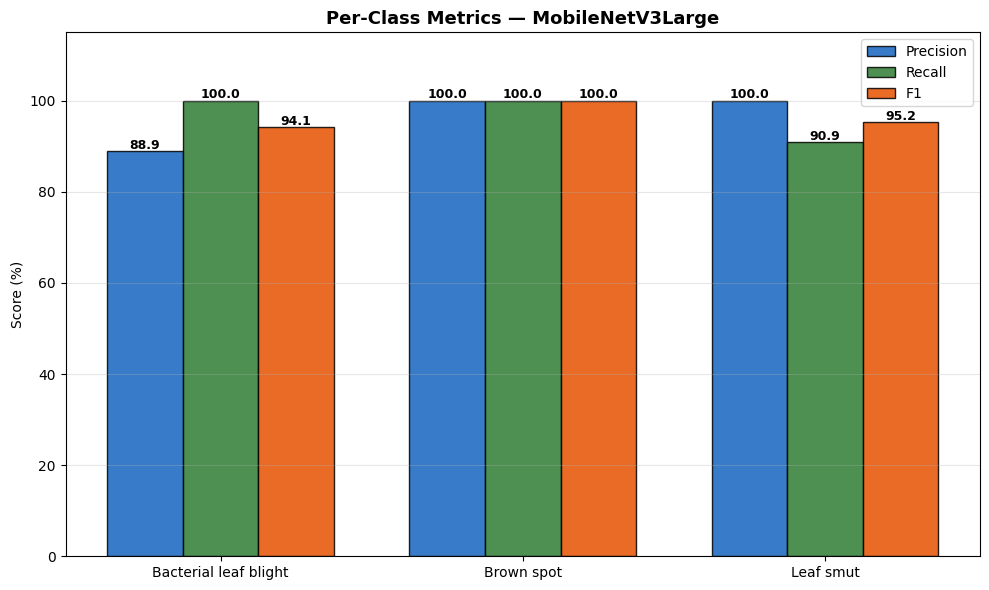

In [ ]:
print(f"\n{'='*60}")
print(f"  DETAILED CLASSIFICATION REPORT — {best_name}")
print(f"{'='*60}")
print(classification_report(y_true_b, y_pred_b, target_names=class_names, digits=4))

report_dict = {}
y_true_arr = np.array(y_true_b)
y_pred_arr = np.array(y_pred_b)

for cls_idx, cls_name in enumerate(class_names):
    report_dict[cls_name] = {
        "Precision": precision_score(y_true_arr, y_pred_arr,
                                     labels=[cls_idx], average="macro",
                                     zero_division=0),
        "Recall":    recall_score(y_true_arr, y_pred_arr,
                                  labels=[cls_idx], average="macro",
                                  zero_division=0),
        "F1":        f1_score(y_true_arr, y_pred_arr,
                              labels=[cls_idx], average="macro",
                              zero_division=0),
    }

rdf = pd.DataFrame(report_dict).T
x = np.arange(len(class_names))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, (col, color) in enumerate(zip(["Precision","Recall","F1"],
                                      ["#1565C0","#2E7D32","#E65100"])):
    bars = ax.bar(x + i*w, rdf[col]*100, w, label=col, color=color,
                  edgecolor="black", alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f"{b.get_height():.1f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x + w)
ax.set_xticklabels(class_names)
ax.set_ylabel("Score (%)")
ax.set_title(f"Per-Class Metrics — {best_name}", fontsize=13, fontweight="bold")
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# Saving Best Model

In [ ]:
best_model.save(f"best_model_{best_name}.keras")
print(f"Best model saved → best_model_{best_name}.keras")

output_files = [
    "model_comparison_results.csv",
    "sample_images.png",
    "class_distribution.png",
    "augmentation_examples.png",
    "learning_curves.png",
    "accuracy_comparison.png",
    "metrics_comparison.png",
    "f1_ranking.png",
    "complexity_vs_accuracy.png",
    "confusion_matrices_all.png",
    f"confusion_matrix_{best_name}.png",
    "radar_top2.png",
    "per_class_metrics.png",
    f"best_model_{best_name}.keras",
]

with zipfile.ZipFile("rice_disease_results.zip", "w") as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✓ {f}")

print("\nDownloading results zip...")
from google.colab import files
files.download("rice_disease_results.zip")

Best model saved → best_model_MobileNetV3Large.keras
  ✓ model_comparison_results.csv
  ✓ sample_images.png
  ✓ class_distribution.png
  ✓ augmentation_examples.png
  ✓ learning_curves.png
  ✓ accuracy_comparison.png
  ✓ metrics_comparison.png
  ✓ f1_ranking.png
  ✓ complexity_vs_accuracy.png
  ✓ confusion_matrices_all.png
  ✓ confusion_matrix_MobileNetV3Large.png
  ✓ radar_top2.png
  ✓ per_class_metrics.png
  ✓ best_model_MobileNetV3Large.keras



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# FINAL SUMMARY

In [ ]:
print("\n" + "="*70)
print("  FINAL ANALYSIS SUMMARY")
print("="*70)

print(f"\n▸ Dataset: {sum(counts.values())} images | {NUM_CLASSES} classes | Balanced")
for c in class_names:
    print(f"    {c}: {counts[c]} images")

print(f"\n▸ Train/Val Split: 80/20")
print(f"  Training samples  : {sum(counts.values()) - int(sum(counts.values())*0.2)}")
print(f"  Validation samples: {int(sum(counts.values())*0.2)}")

print(f"\n▸ Models Evaluated: {len(results_df)}")
print(results_df.to_string(index=False))

print(f"\n▸ Best Model: {best_name}")
best_row = results_df.iloc[0]
print(f"  Accuracy : {best_row['Accuracy']*100:.2f}%")
print(f"  Precision: {best_row['Precision']*100:.2f}%")
print(f"  Recall   : {best_row['Recall']*100:.2f}%")
print(f"  F1 Score : {best_row['F1 Score']*100:.2f}%")
print(f"  Parameters: {best_row['Params (M)']}M")

print(f"\n▸ Classification Report ({best_name}):")
print(classification_report(y_true_b, y_pred_b, target_names=class_names, digits=4))

print(f"\n▸ Confusion Matrix ({best_name}):")
print(pd.DataFrame(confusion_matrix(y_true_b, y_pred_b),
                   index=class_names, columns=class_names))

print("\n" + "="*70)
print("  END OF SUMMARY")
print("="*70)


  FINAL ANALYSIS SUMMARY

▸ Dataset: 120 images | 3 classes | Balanced
    Bacterial leaf blight: 40 images
    Brown spot: 40 images
    Leaf smut: 40 images

▸ Train/Val Split: 80/20
  Training samples  : 96
  Validation samples: 24

▸ Models Evaluated: 5
           Model  Accuracy  Precision  Recall  F1 Score  Params (M)
MobileNetV3Large    0.9583     0.9630  0.9583    0.9586        3.12
      ResNet50V2    0.9167     0.9295  0.9167    0.9097       23.83
EfficientNetV2B0    0.9167     0.9295  0.9167    0.9164        6.08
     DenseNet121    0.8750     0.8715  0.8750    0.8708        7.17
      Custom_CNN    0.4583     0.2101  0.4583    0.2881        2.52

▸ Best Model: MobileNetV3Large
  Accuracy : 95.83%
  Precision: 96.30%
  Recall   : 95.83%
  F1 Score : 95.86%
  Parameters: 3.12M

▸ Classification Report (MobileNetV3Large):
                       precision    recall  f1-score   support

Bacterial leaf blight     0.8889    1.0000    0.9412         8
           Brown spot     1.0